# Module 14: Capstone: From Data to Publication

Each previous module introduced a specific tool or technique in isolation. This module puts them together. Rather than demonstrating features, it walks through two complete figure-building cases the way you would encounter them in real research: starting from data, making deliberate decisions about representation and layout, and ending with a figure ready for submission. Every decision is explained, not just the code that implements it.

## What this module is

Case 1 builds a phase diagram from scratch: a figure type with specific conventions that anyone in polymer thermodynamics will recognize, and where every visual element carries physical meaning. Case 2 assembles a multi-panel research figure from the datasets introduced in Module 08, using `GridSpec` to arrange panels with different geometries and walking through every layout decision. Both cases apply the publication styling from Module 13 throughout, not as a final step, but as part of the construction process.

## Imports and Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
from mpl_toolkits.mplot3d import Axes3D
import os

# Write the custom style file if it is not already present
os.makedirs('styles', exist_ok=True)
STYLE_PATH = 'styles/custom.mplstyle'

if not os.path.exists(STYLE_PATH):
    style_content = """\
font.family        : serif
font.size          : 8
axes.titlesize     : 8
axes.labelsize     : 8
xtick.labelsize    : 7
ytick.labelsize    : 7
legend.fontsize    : 7
lines.linewidth    : 1.0
axes.linewidth     : 0.8
xtick.direction    : out
ytick.direction    : out
xtick.major.size   : 3.5
ytick.major.size   : 3.5
xtick.minor.size   : 2.0
ytick.minor.size   : 2.0
xtick.major.width  : 0.8
ytick.major.width  : 0.8
axes.spines.top    : False
axes.spines.right  : False
axes.grid          : False
figure.dpi         : 150
savefig.dpi        : 300
savefig.bbox       : tight
legend.frameon     : False
legend.borderpad   : 0.4
axes.prop_cycle    : cycler('color', ['0077BB', '33BBEE', '009988', 'EE7733', 'CC3311', 'EE3377', 'BBBBBB'])
"""
    with open(STYLE_PATH, 'w') as f:
        f.write(style_content)
    print(f'Style file written to {STYLE_PATH}')
else:
    print(f'Style file found at {STYLE_PATH}')

Style file found at styles/custom.mplstyle


---
## Case 1: UCST and LCST Phase Diagram

### Background

Many polymer-solvent systems exhibit a temperature-dependent miscibility gap. In a system with an upper critical solution temperature (UCST), the two components mix freely at high temperature and phase-separate into two coexisting phases on cooling below the phase boundary. The lower critical solution temperature (LCST) is the opposite: the system is miscible at low temperature and phase-separates on heating. Some polymer-solvent pairs, such as certain aqueous polymer solutions, exhibit both boundaries simultaneously, forming a closed miscibility loop with a one-phase window bounded above by the LCST curve and below by the UCST curve. Outside that window, the system splits into two phases.

### Generating the synthetic phase boundary data

The shape of each boundary is inspired by Flory-Huggins theory. The binodal curve for a symmetric system is concave up for UCST (a minimum at the critical volume fraction) and concave down for LCST (a maximum). We parameterize both curves as polynomials of volume fraction, setting the critical points and the endpoints at the pure-component limits.

In [2]:
# Polymer volume fraction axis: 0 to 1
phi = np.linspace(0.01, 0.99, 400)

# UCST branch: concave-up curve with a minimum (critical point) near phi = 0.35
# Shape: a quadratic-like curve, scaled to reach the pure-component axes
phi_c_ucst = 0.35
T_ucst_min = 220.0    # minimum temperature on the UCST curve (critical point, K)

def ucst_curve(phi, phi_c, T_min, curvature=420.0):
    """Symmetric-ish UCST binodal. Higher curvature = flatter near the critical point."""
    return T_min + curvature * (phi - phi_c)**2 / (phi * (1 - phi) + 0.05)

T_ucst = ucst_curve(phi, phi_c_ucst, T_ucst_min, curvature=380.0)

# LCST branch: concave-down curve with a maximum near phi = 0.40
phi_c_lcst = 0.40
T_lcst_max = 370.0    # maximum temperature on the LCST curve (critical point, K)

def lcst_curve(phi, phi_c, T_max, curvature=380.0):
    """Symmetric-ish LCST binodal."""
    return T_max - curvature * (phi - phi_c)**2 / (phi * (1 - phi) + 0.05)

T_lcst = lcst_curve(phi, phi_c_lcst, T_lcst_max, curvature=330.0)

# Keep only the region where the UCST curve is below the LCST curve
# (the closed miscibility window)
window_mask = T_ucst < T_lcst
phi_win  = phi[window_mask]
T_ucst_w = T_ucst[window_mask]
T_lcst_w = T_lcst[window_mask]

print(f'Window spans phi = {phi_win[0]:.2f} to {phi_win[-1]:.2f}')
print(f'UCST critical point: T = {T_ucst_w.min():.1f} K at phi ~ {phi_win[np.argmin(T_ucst_w)]:.2f}')
print(f'LCST critical point: T = {T_lcst_w.max():.1f} K at phi ~ {phi_win[np.argmax(T_lcst_w)]:.2f}')

Window spans phi = 0.17 to 0.62
UCST critical point: T = 220.0 K at phi ~ 0.35
LCST critical point: T = 370.0 K at phi ~ 0.40


### Step 1: Set up the axes

The temperature axis runs vertically (y) and the composition axis (polymer volume fraction) runs horizontally (x). This is the standard orientation for binary phase diagrams in polymer thermodynamics. The axis limits need to include a margin around the closed loop so the two-phase regions above and below the window are visible. We set the y limits to span from below the UCST critical point to above the LCST critical point, and the x limits to span the full composition range.

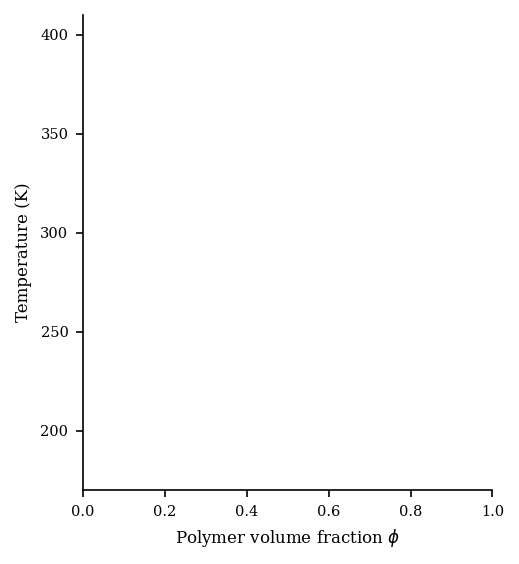

In [3]:
with plt.style.context(STYLE_PATH):
    fig_pd, ax_pd = plt.subplots(figsize=(3.5, 3.8))

    ax_pd.set_xlim(0.0, 1.0)
    ax_pd.set_ylim(170, 410)
    ax_pd.set_xlabel('Polymer volume fraction $\\phi$')
    ax_pd.set_ylabel('Temperature (K)')

    plt.tight_layout()
    plt.show()

The serif font and open frame from the custom style are already active. The y-axis range of 170 to 410 K gives approximately 25 K of margin below the UCST minimum (220 K) and above the LCST maximum (370 K), which is enough to show the two-phase regions without compressing the loop.

### Step 2: Add the phase boundary curves

Both boundary curves are drawn as solid lines. The convention in phase diagrams is that the boundary itself (the binodal) is drawn in black or a neutral dark color, not in the color that will be used for the shaded regions, so that the line remains readable against the shading.

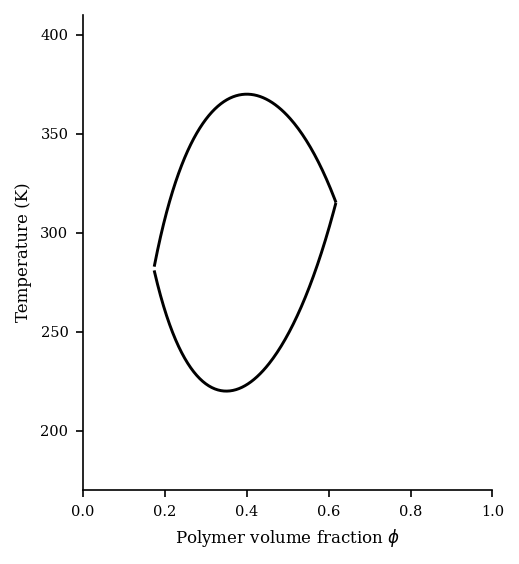

In [4]:
with plt.style.context(STYLE_PATH):
    fig_pd, ax_pd = plt.subplots(figsize=(3.5, 3.8))

    # Phase boundary lines: black, slightly heavier than the default 1 pt
    ax_pd.plot(phi_win, T_ucst_w, color='black', linewidth=1.4, zorder=3)
    ax_pd.plot(phi_win, T_lcst_w, color='black', linewidth=1.4, zorder=3)

    ax_pd.set_xlim(0.0, 1.0)
    ax_pd.set_ylim(170, 410)
    ax_pd.set_xlabel('Polymer volume fraction $\\phi$')
    ax_pd.set_ylabel('Temperature (K)')

    plt.tight_layout()
    plt.show()

### Step 3: Shade the two-phase and one-phase regions

The one-phase (miscible) region is the interior of the closed loop. The two-phase (immiscible) regions are everything outside the loop. `fill_between` can shade both. The one-phase region is shaded with a light, warm color; the two-phase regions with a cooler, more neutral tone. Both use low alpha so the curves drawn on top remain visible. The `zorder` argument ensures the shading sits below the boundary lines.

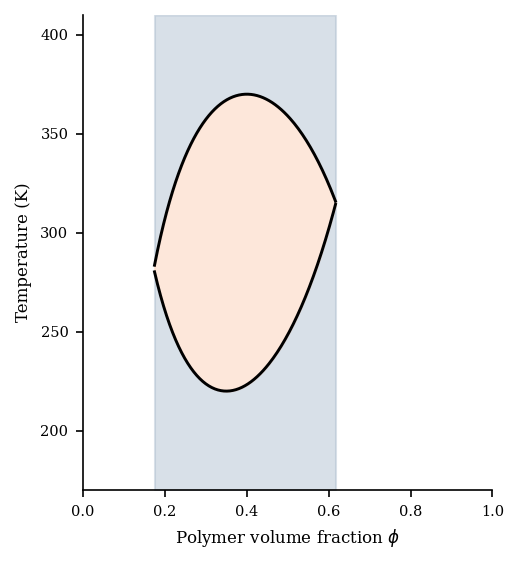

In [5]:
with plt.style.context(STYLE_PATH):
    fig_pd, ax_pd = plt.subplots(figsize=(3.5, 3.8))

    # Two-phase region below the UCST curve: fill from bottom of axes to UCST
    ax_pd.fill_between(
        phi_win, 170, T_ucst_w,
        color='#AABBCC', alpha=0.45, zorder=1, label='Two-phase'
    )

    # Two-phase region above the LCST curve: fill from LCST to top of axes
    ax_pd.fill_between(
        phi_win, T_lcst_w, 410,
        color='#AABBCC', alpha=0.45, zorder=1
    )

    # One-phase (miscible) region: interior of the loop
    ax_pd.fill_between(
        phi_win, T_ucst_w, T_lcst_w,
        color='#FDDBC7', alpha=0.65, zorder=2, label='One-phase'
    )

    # Phase boundary lines on top of shading
    ax_pd.plot(phi_win, T_ucst_w, color='black', linewidth=1.4, zorder=3)
    ax_pd.plot(phi_win, T_lcst_w, color='black', linewidth=1.4, zorder=3)

    ax_pd.set_xlim(0.0, 1.0)
    ax_pd.set_ylim(170, 410)
    ax_pd.set_xlabel('Polymer volume fraction $\\phi$')
    ax_pd.set_ylabel('Temperature (K)')

    plt.tight_layout()
    plt.show()

The shading immediately communicates the topology: one-phase region inside the loop, two-phase regions above and below. The color choice is deliberately not red-green: the warm cream interior and the cool blue-grey exterior are distinguishable under the two most common forms of color vision deficiency. The `zorder` hierarchy (shading at 1 and 2, curves at 3) ensures the boundary lines are never obscured by the fill.

### Step 4: Add annotations and critical point markers

The UCST and LCST labels belong on the figure itself, not only in the caption, because a reader scanning the figure before the text needs to orient immediately. A filled circle marks each critical point. Text annotations are placed with `ax.annotate` using `xytext` offsets to avoid overlapping the curves.

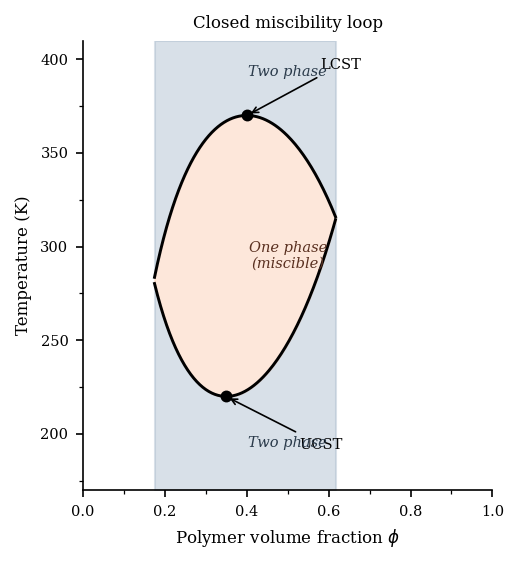

Phase diagram saved.


In [6]:
# Locate the critical point coordinates for annotation
idx_ucst_cp = np.argmin(T_ucst_w)
idx_lcst_cp = np.argmax(T_lcst_w)
phi_ucst_cp, T_ucst_cp = phi_win[idx_ucst_cp], T_ucst_w[idx_ucst_cp]
phi_lcst_cp, T_lcst_cp = phi_win[idx_lcst_cp], T_lcst_w[idx_lcst_cp]

with plt.style.context(STYLE_PATH):
    fig_pd, ax_pd = plt.subplots(figsize=(3.5, 3.8))

    # Shaded regions (same as Step 3)
    ax_pd.fill_between(phi_win, 170, T_ucst_w, color='#AABBCC', alpha=0.45, zorder=1)
    ax_pd.fill_between(phi_win, T_lcst_w, 410,  color='#AABBCC', alpha=0.45, zorder=1)
    ax_pd.fill_between(phi_win, T_ucst_w, T_lcst_w, color='#FDDBC7', alpha=0.65, zorder=2)

    # Phase boundary curves
    ax_pd.plot(phi_win, T_ucst_w, color='black', linewidth=1.4, zorder=3)
    ax_pd.plot(phi_win, T_lcst_w, color='black', linewidth=1.4, zorder=3)

    # Critical point markers
    ax_pd.scatter([phi_ucst_cp], [T_ucst_cp], color='black', s=22, zorder=5)
    ax_pd.scatter([phi_lcst_cp], [T_lcst_cp], color='black', s=22, zorder=5)

    # UCST annotation: arrow pointing up to the critical point from below
    ax_pd.annotate(
        'UCST',
        xy=(phi_ucst_cp, T_ucst_cp),
        xytext=(phi_ucst_cp + 0.18, T_ucst_cp - 28),
        fontsize=7,
        arrowprops=dict(arrowstyle='->', color='black', lw=0.8),
        ha='left'
    )

    # LCST annotation: arrow pointing down to the critical point from above
    ax_pd.annotate(
        'LCST',
        xy=(phi_lcst_cp, T_lcst_cp),
        xytext=(phi_lcst_cp + 0.18, T_lcst_cp + 25),
        fontsize=7,
        arrowprops=dict(arrowstyle='->', color='black', lw=0.8),
        ha='left'
    )

    # Region labels placed in the interior of each region
    ax_pd.text(0.50, 295, 'One phase\n(miscible)',
               ha='center', va='center', fontsize=7, style='italic', color='#5A3020')
    ax_pd.text(0.50, 195, 'Two phase',
               ha='center', va='center', fontsize=7, style='italic', color='#2A3A4A')
    ax_pd.text(0.50, 393, 'Two phase',
               ha='center', va='center', fontsize=7, style='italic', color='#2A3A4A')

    ax_pd.set_xlim(0.0, 1.0)
    ax_pd.set_ylim(170, 410)
    ax_pd.set_xlabel('Polymer volume fraction $\\phi$')
    ax_pd.set_ylabel('Temperature (K)')
    ax_pd.set_title('Closed miscibility loop')

    # Minor ticks on both axes
    ax_pd.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    ax_pd.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))

    plt.tight_layout()
    fig_pd.savefig('phase_diagram.pdf', bbox_inches='tight')
    fig_pd.savefig('phase_diagram.png', dpi=300, bbox_inches='tight')
    plt.show()

print('Phase diagram saved.')

The finished phase diagram encodes five distinct pieces of information: the two boundary curves, their critical points, the one-phase region, the two two-phase regions, and the UCST/LCST labels. Every element was added for a specific reason. The only things not present are a legend (replaced by direct region labels, which are always preferable when space allows) and grid lines (suppressed by the style file because the phase boundary curves are the primary reference lines in this figure type).

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.patches import Rectangle

# Set up the figure with 2x4 subplots
fig = plt.figure(figsize=(20, 12), dpi=300)  # Increased height for legend
plt.rcParams['axes.labelsize'] = 17
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['axes.titlepad'] = 20
plt.rcParams['axes.titleweight'] = 'bold'
# Common x values (polymer volume fraction)
phi = np.linspace(0, 1, 1000)
# Temperature range for χ plots
T = np.linspace(0, 80, 1000)

# Define style constants
phase_boundary_style = {'color': 'orchid', 'alpha': 0.5, 'linestyle': '-', 'linewidth': 1.5}
ucst_style = {'color': 'royalblue', 'linestyle': '--', 'linewidth': 1}
lcst_style = {'color': 'darkred', 'linestyle': '--', 'linewidth': 1}
chi_style = {'color': 'purple', 'linestyle': '-', 'linewidth': 1.5}
immiscible_style = {'facecolor': 'orchid', 'alpha': 0.1, 'hatch': '//', 'edgecolor': 'gray'}
critical_chi_style = {'color': 'orchid', 'alpha': 0.5, 'linestyle': '-', 'linewidth': 1.5}
one_phase_color = 'lightgray'
alphaa = 0.35


# 1. PNIPAM - LCST only (around 32°C)
ax1 = plt.subplot(241)
ax1.set_facecolor(one_phase_color)  # Set background color
ax1.patch.set_alpha(alphaa)
T1 = 32 + 30 * (2 * (phi - 0.5)**2)
ax1.plot(phi, T1, **phase_boundary_style)
vertices1 = np.vstack((np.column_stack((phi, T1)), [1, 80], [0, 80]))
ax1.add_patch(Polygon(vertices1, **immiscible_style))
ax1.axhline(y=32, **lcst_style)
ax1.set_title('PNIPAM in Water\n(LCST only)')
ax1.set_ylim(0, 80)
ax1.set_xlim(0, 1)
ax1.set_xlabel('Polymer Volume Fraction (φ)')
ax1.set_ylabel('Temperature (°C)')

# χ vs T for PNIPAM - Hyperbolic tangent
ax5 = plt.subplot(245)
# Add background rectangles
ax5.add_patch(Rectangle((0, 0.5), 80, 0.5, **immiscible_style))
ax5.add_patch(Rectangle((0, 0), 80, 0.5, facecolor=one_phase_color, alpha=alphaa))
chi_pnipam = 0.5 + 0.3 * np.tanh((T - 32) / 10)
ax5.axvline(x=32, **lcst_style)  # LCST line
ax5.plot(T, chi_pnipam, **chi_style)
ax5.axhline(y=0.5, **critical_chi_style)
ax5.set_xlabel('Temperature (°C)')
ax5.set_ylabel('χ Parameter')
ax5.set_ylim(0, 1)
ax5.set_xlim(0, 80)

# 2. PAA/PAAm - UCST only
ax2 = plt.subplot(242)
ax2.set_facecolor(one_phase_color)  # Set background color
ax2.patch.set_alpha(alphaa)
T2 = 45 - 30 * (2 * (phi - 0.5)**2)
ax2.plot(phi, T2, **phase_boundary_style)
vertices2 = np.vstack(([0, 0], [1, 0], np.column_stack((phi[::-1], T2[::-1]))))
ax2.add_patch(Polygon(vertices2, **immiscible_style))
ax2.axhline(y=45, **ucst_style)
ax2.set_title('Polystyrene in Cyclohexane\n(UCST only)')
ax2.set_ylim(0, 80)
ax2.set_xlim(0, 1)
ax2.set_xlabel('Polymer Volume Fraction (φ)')
ax2.set_ylabel('Temperature (°C)')

# χ vs T for PAA/PAAm - Hyperbolic tangent
ax6 = plt.subplot(246)
ax6.add_patch(Rectangle((0, 0.5), 80, 0.5, **immiscible_style))
ax6.add_patch(Rectangle((0, 0), 80, 0.5, facecolor=one_phase_color, alpha=alphaa))
chi_paa = 0.5 - 0.3 * np.tanh((T - 45) / 10)
ax6.axvline(x=45, **ucst_style)  # UCST line
ax6.plot(T, chi_paa, **chi_style)
ax6.axhline(y=0.5, **critical_chi_style)
ax6.set_xlabel('Temperature (°C)')
ax6.set_ylabel('χ Parameter')
ax6.set_ylim(0, 1)
ax6.set_xlim(0, 80)

# 3. PHEMA in water/ethanol - UCST above LCST
ax3 = plt.subplot(243)
ax3.set_facecolor(one_phase_color)  # Set background color
ax3.patch.set_alpha(alphaa)
T3_upper = 65 - 30 * (2 * (phi - 0.5)**2)
T3_lower = 35 + 30 * (2 * (phi - 0.5)**2)
ax3.plot(phi, T3_upper, **phase_boundary_style)
ax3.plot(phi, T3_lower, **phase_boundary_style)
vertices3_middle = np.vstack((np.column_stack((phi, T3_lower)),
                            np.column_stack((phi[::-1], T3_upper[::-1]))))
ax3.add_patch(Polygon(vertices3_middle, **immiscible_style))
ax3.axhline(y=65, **ucst_style)
ax3.axhline(y=35, **lcst_style)
ax3.set_title('PHEMA in Water/Ethanol\n(UCST above LCST)')
ax3.set_ylim(0, 80)
ax3.set_xlim(0, 1)
ax3.set_xlabel('Polymer Volume Fraction (φ)')
ax3.set_ylabel('Temperature (°C)')

# χ vs T for PHEMA - Bell-shaped curve
ax7 = plt.subplot(247)
ax7.add_patch(Rectangle((0, 0.5), 80, 0.5, **immiscible_style))
ax7.add_patch(Rectangle((0, 0), 80, 0.5, facecolor=one_phase_color, alpha=alphaa))
chi_phema = 0.2 + 0.3 * (np.tanh((T - 35) / 4) - np.tanh((T - 65) / 4))
ax7.axvline(x=35, **lcst_style)  # LCST line
ax7.axvline(x=65, **ucst_style)  # UCST line
ax7.plot(T, chi_phema, **chi_style)
ax7.axhline(y=0.5, **critical_chi_style)
ax7.set_xlabel('Temperature (°C)')
ax7.set_ylabel('χ Parameter')
ax7.set_ylim(0, 1)
ax7.set_xlim(0, 80)

# 4. PMMA in alcohol mixtures - LCST above UCST
ax4 = plt.subplot(244)
ax4.set_facecolor(one_phase_color)  # Set background color
ax4.patch.set_alpha(alphaa)
T4_lower = 40 - 30 * (2 * (phi - 0.5)**2)
T4_upper = 60 + 30 * (2 * (phi - 0.5)**2)
ax4.plot(phi, T4_upper, **phase_boundary_style)
ax4.plot(phi, T4_lower, **phase_boundary_style)
vertices4_upper = np.vstack((np.column_stack((phi, T4_upper)), [1, 80], [0, 80]))
vertices4_lower = np.vstack(([0, 0], [1, 0], np.column_stack((phi[::-1], T4_lower[::-1]))))
ax4.add_patch(Polygon(vertices4_upper, **immiscible_style))
ax4.add_patch(Polygon(vertices4_lower, **immiscible_style))
ax4.axhline(y=60, **lcst_style)
ax4.axhline(y=40, **ucst_style)
ax4.set_title('PMMA in Water/Ethanol\n(LCST above UCST)')
ax4.set_ylim(0, 80)
ax4.set_xlim(0, 1)
ax4.set_xlabel('Polymer Volume Fraction (φ)')
ax4.set_ylabel('Temperature (°C)')

# χ vs T for PMMA - Inverted bell shape
ax8 = plt.subplot(248)
ax8.add_patch(Rectangle((0, 0.5), 80, 0.5, **immiscible_style))
ax8.add_patch(Rectangle((0, 0), 80, 0.5, facecolor=one_phase_color, alpha=alphaa))
chi_pmma = 0.8 - 0.3 * (np.tanh((T - 40) / 4) - np.tanh((T - 60) / 4))
ax8.axvline(x=40, **ucst_style)  # UCST line
ax8.axvline(x=60, **lcst_style)  # LCST line
ax8.plot(T, chi_pmma, **chi_style)
ax8.axhline(y=0.5, **critical_chi_style)
ax8.set_xlabel('Temperature (°C)')
ax8.set_ylabel('χ Parameter')
ax8.set_ylim(0, 1)
ax8.set_xlim(0, 80)

# Create custom legend at the bottom of the figure
legend_elements = [
    plt.Line2D([0], [0], **phase_boundary_style, label='Phase Boundary'),
    plt.Line2D([0], [0], **ucst_style, label='UCST'),
    plt.Line2D([0], [0], **lcst_style, label='LCST'),
    plt.Rectangle((0, 0), 1, 1, **immiscible_style, label='Two-Phase Region'),
    plt.Rectangle((0, 0), 1, 1, facecolor=one_phase_color, label='One-Phase Region'),
    plt.Line2D([0], [0], **chi_style, label='χ Parameter'),
    plt.Line2D([0], [0], **critical_chi_style, label='Critical χ (0.5)')
]

# Place legend at the bottom with increased font size
fig.legend(handles=legend_elements, loc='center', bbox_to_anchor=(0.5, 0.08),
          ncol=7, frameon=False, fontsize=18)

plt.tight_layout()
# Adjust layout to accommodate legend at bottom
plt.subplots_adjust(bottom=0.18, hspace=0.2)
plt.savefig("./result/CST.png", dpi=300, bbox_inches='tight')

---
## Case 2: Multi-panel Research Figure

### Why GridSpec

The three panels in this figure have fundamentally different sizes and types: a large 3D scatter on the left, a 2D contour map on the upper right, and a 2D line plot on the lower right. `plt.subplots` assumes a rectangular grid with uniform cell sizes. `GridSpec` defines a grid where rows and columns can have different heights and widths, and individual axes can span multiple rows or columns. It is the right tool whenever the figure layout is not a simple uniform grid.

### Rebuild the datasets from Module 08

In [8]:
# RAFT polymerization search space data
ri_lo, ri_hi     = 0.5,  10.0
mr_lo, mr_hi     = 15.0, 36.0
time_lo, time_hi = 0.1,  20.0

def log_norm(values, lo, hi):
    return (np.log(values) - np.log(lo)) / (np.log(hi) - np.log(lo))

ri_init   = np.array([0.6,  1.2,  2.5,  5.0,  9.0,  0.8,  3.5,  7.0,  1.8])
mr_init   = np.array([16.0, 20.0, 32.0, 18.0, 28.0, 35.0, 24.0, 16.5, 30.0])
time_init = np.array([0.2,  1.0,  5.0,  10.0, 18.0, 3.0,  0.5,  7.0,  14.0])

ri_r1   = np.array([1.0,  2.0,  4.0,  6.0,  8.0,  1.5,  3.0,  5.5,  7.5,  2.8])
mr_r1   = np.array([15.5, 17.0, 19.0, 22.0, 24.5, 16.0, 21.0, 23.0, 18.5, 20.5])
time_r1 = np.array([0.15, 0.4,  1.2,  2.5,  4.5,  0.8,  1.8,  3.2,  0.3,  2.0])

ri_r2   = np.array([1.2,  3.5,  6.0,  9.5,  2.0,  4.5,  7.0,  1.5,  5.0])
mr_r2   = np.array([26.0, 29.0, 32.0, 34.5, 27.5, 31.0, 35.5, 28.0, 33.0])
time_r2 = np.array([6.0,  9.0,  13.0, 18.5, 7.5,  11.0, 16.0, 8.5,  14.5])

xi, yi, zi = log_norm(ri_init, ri_lo, ri_hi), log_norm(mr_init, mr_lo, mr_hi), log_norm(time_init, time_lo, time_hi)
x1, y1, z1 = log_norm(ri_r1,  ri_lo, ri_hi), log_norm(mr_r1,  mr_lo, mr_hi), log_norm(time_r1,  time_lo, time_hi)
x2, y2, z2 = log_norm(ri_r2,  ri_lo, ri_hi), log_norm(mr_r2,  mr_lo, mr_hi), log_norm(time_r2,  time_lo, time_hi)

print(f'RAFT data: {len(xi)+len(x1)+len(x2)} experiments across 3 rounds')

RAFT data: 28 experiments across 3 rounds


In [9]:
# Injection molding temperature field
x_pos  = np.linspace(0, 200, 80)
t_fill = np.linspace(0, 5, 60)
X_grid, T_grid = np.meshgrid(x_pos, t_fill)

T_inject, T_mold, x_decay, t_decay = 240.0, 200.0, 120.0, 6.0
temp_field = T_mold + (T_inject - T_mold) * np.exp(-X_grid / x_decay) * np.exp(-T_grid / t_decay)

# Cross-section at x = 50 mm for the bottom-right panel
x_section = 50.0
x_idx_section = np.argmin(np.abs(x_pos - x_section))
temp_section = temp_field[:, x_idx_section]

print(f'Temperature field: {temp_field.shape}  range {temp_field.min():.1f} to {temp_field.max():.1f} °C')

Temperature field: (60, 80)  range 203.3 to 240.0 °C


### Layout decisions

The three panels are arranged in a 2-row, 2-column grid where the left column spans both rows. The column width ratio is set to 1.15:1 (left wider than right) to give the 3D scatter enough room. The row height ratio is 1:1 so the two right panels are equal in height. `wspace` and `hspace` control the whitespace between panels; smaller values are used here than the Matplotlib default to keep the figure compact for a double-column width.

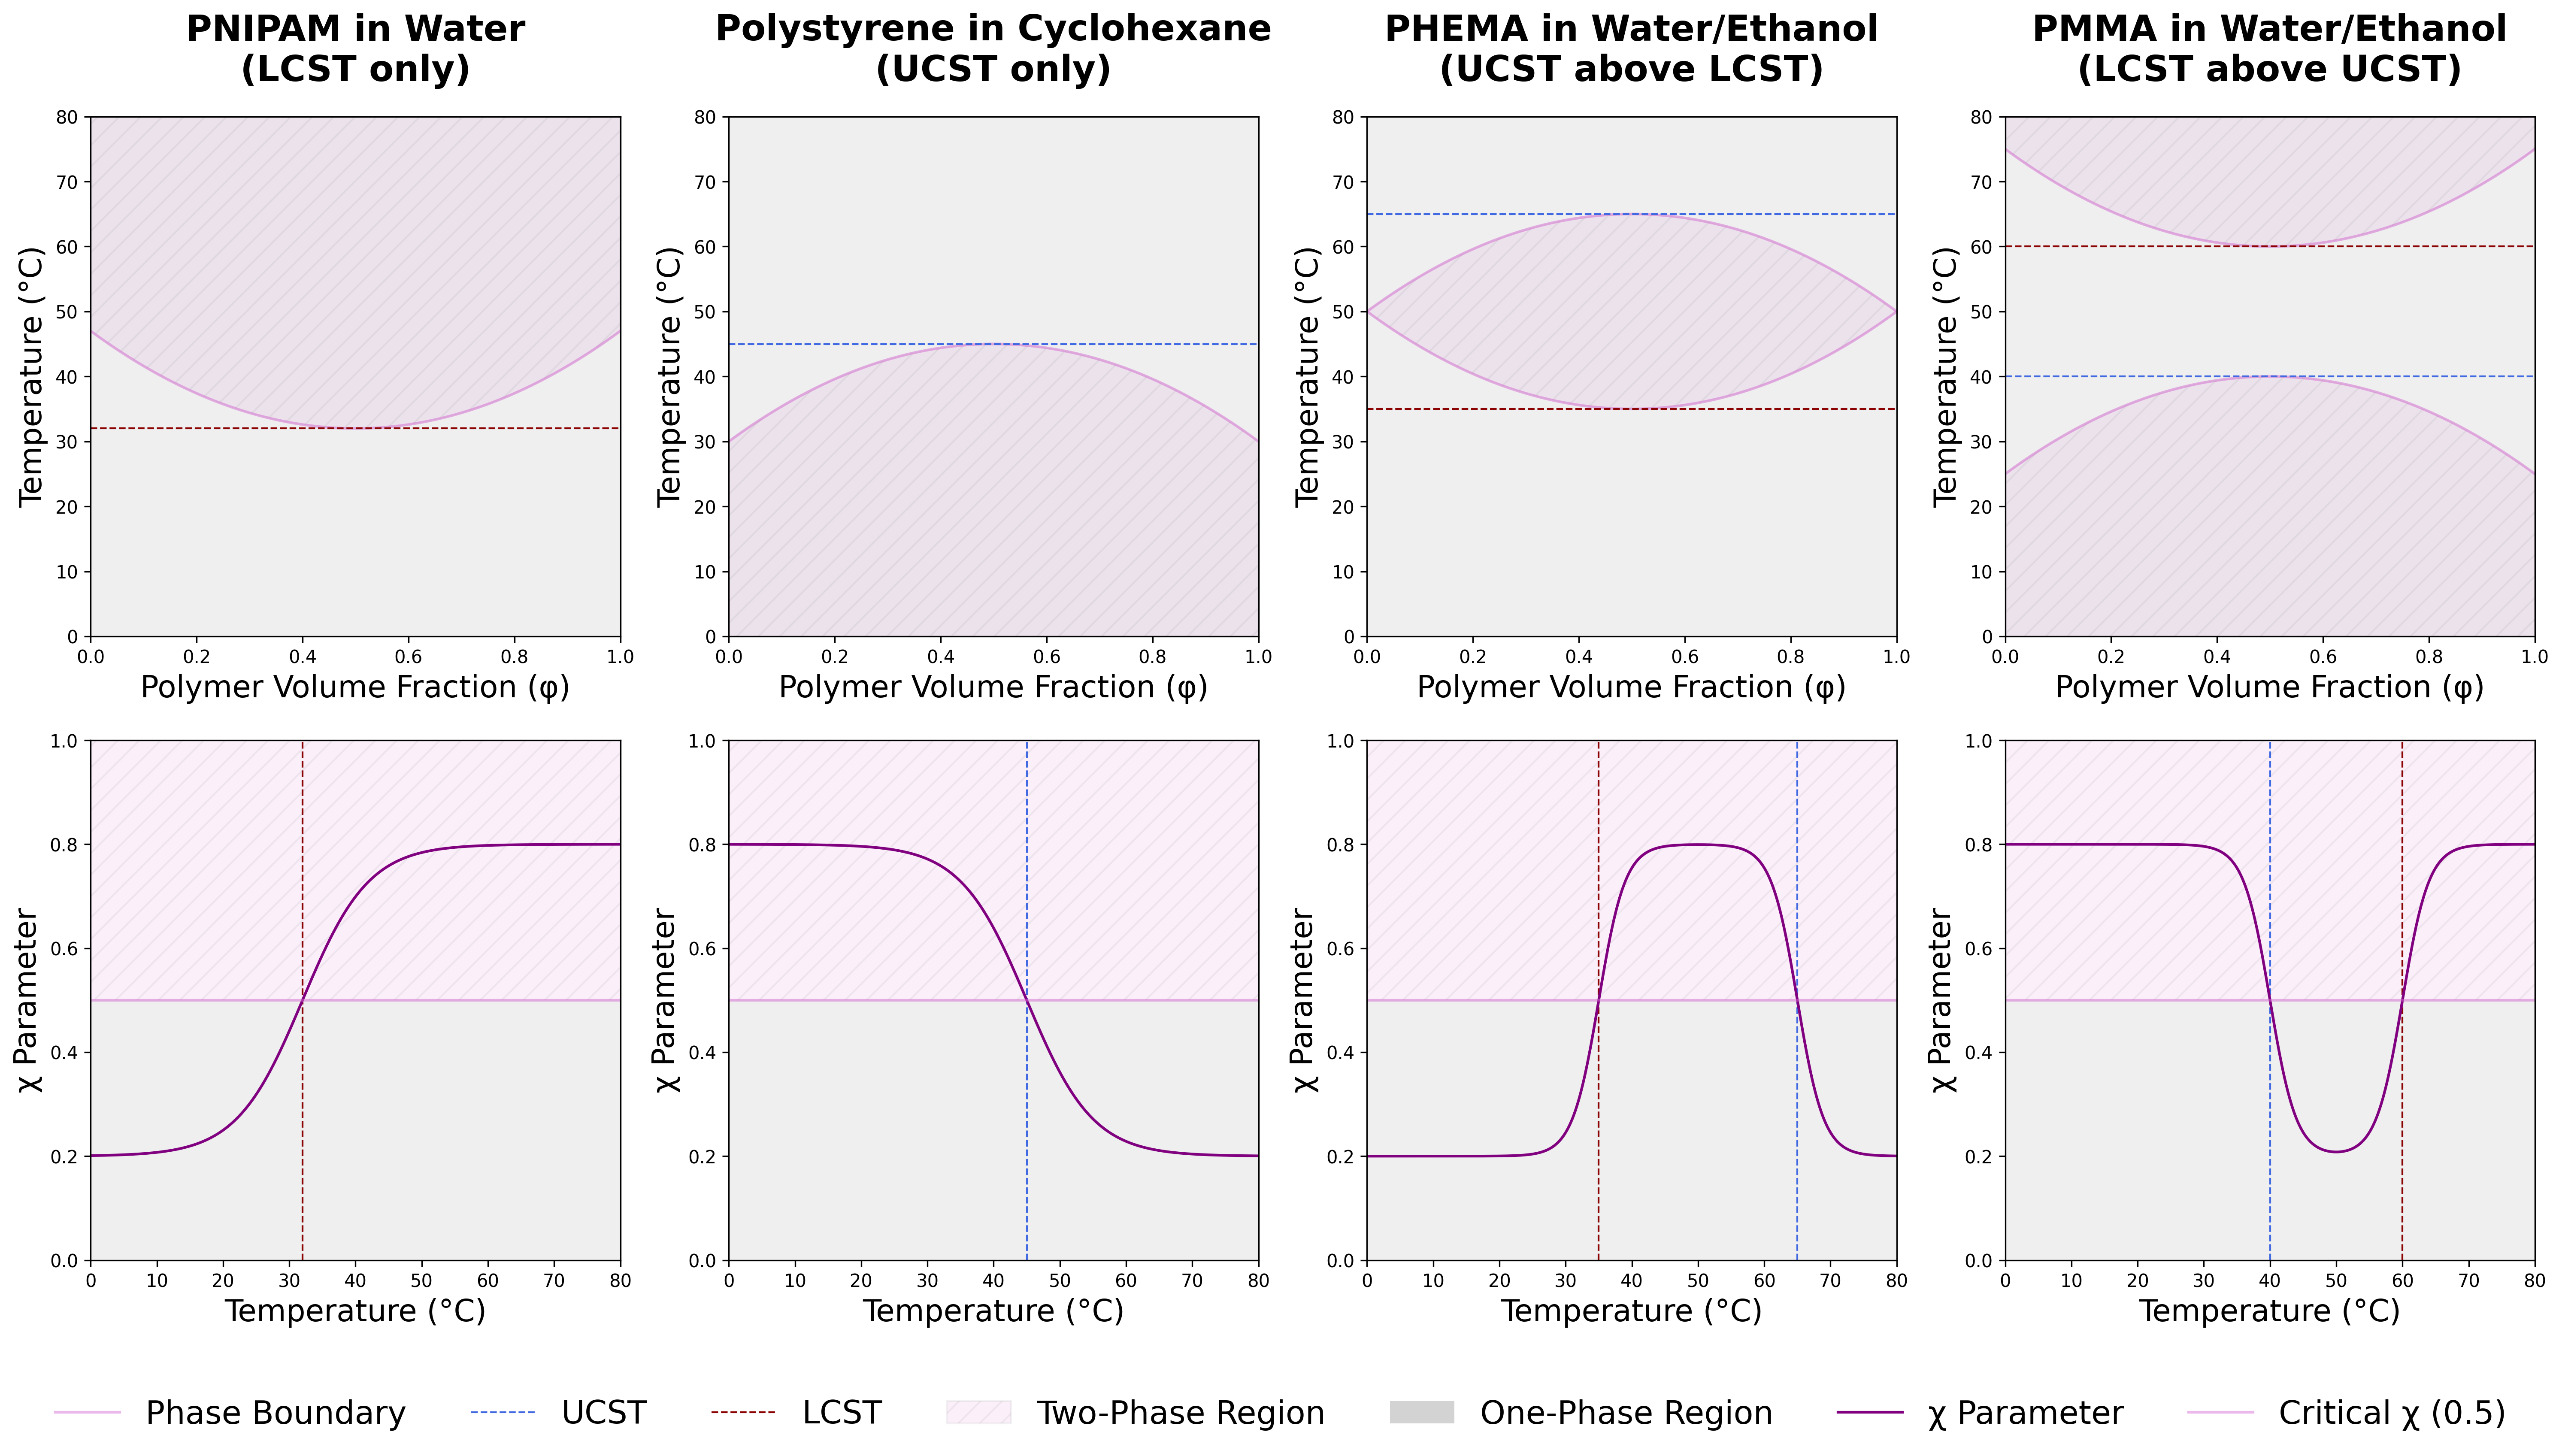

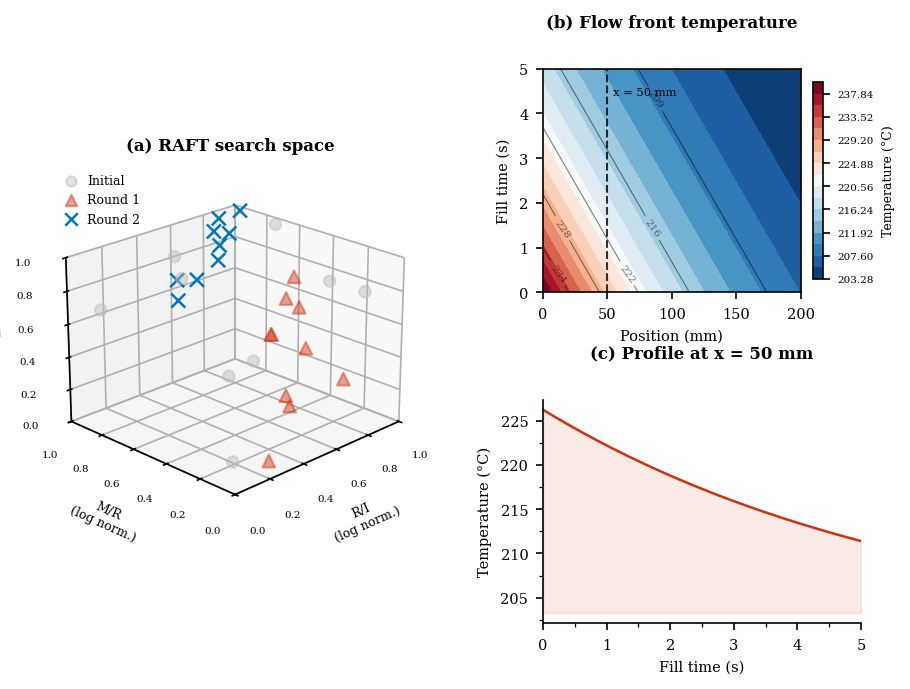

Multi-panel figure saved.


In [10]:
with plt.style.context(STYLE_PATH):

    fig = plt.figure(figsize=(7.0, 4.8))

    # GridSpec: 2 rows, 2 columns
    # width_ratios makes the left column slightly wider for the 3D axes
    # height_ratios keeps the right panels equal in height
    gs = gridspec.GridSpec(
        2, 2,
        width_ratios=[1.15, 1],
        height_ratios=[1, 1],
        wspace=0.38,
        hspace=0.48
    )

    # Left panel: 3D scatter, spans both rows
    # rowspan=2 merges the two left cells into one tall axes
    ax_3d = fig.add_subplot(gs[:, 0], projection='3d')

    # Top-right: contour map
    ax_cnt = fig.add_subplot(gs[0, 1])

    # Bottom-right: cross-section profile
    ax_xsec = fig.add_subplot(gs[1, 1])

    # ------------------------------------------------------------------
    # Left panel: RAFT 3D scatter
    # ------------------------------------------------------------------
    # Viewing angle: elev=22 and azim=225 was chosen in Module 08 because
    # it shows all three axis directions clearly and separates the three
    # rounds visually without any group being hidden behind another.
    ax_3d.scatter(xi, yi, zi, color='#BBBBBB', marker='o', s=30, alpha=0.45,
                  label='Initial')
    ax_3d.scatter(x1, y1, z1, color='#CC3311', marker='^', s=38, alpha=0.45,
                  label='Round 1')
    ax_3d.scatter(x2, y2, z2, color='#0077BB', marker='x', s=45, alpha=1.0,
                  label='Round 2', linewidths=1.2)

    ax_3d.set_xlabel('R/I\n(log norm.)', fontsize=6, labelpad=2)
    ax_3d.set_ylabel('M/R\n(log norm.)', fontsize=6, labelpad=2)
    ax_3d.set_zlabel('Time\n(log norm.)', fontsize=6, labelpad=2)
    ax_3d.tick_params(labelsize=5)
    ax_3d.set_xlim(0, 1); ax_3d.set_ylim(0, 1); ax_3d.set_zlim(0, 1)
    ax_3d.view_init(elev=22, azim=225)
    ax_3d.legend(loc='upper left', fontsize=6, frameon=False,
                 markerscale=0.9, handletextpad=0.3)
    ax_3d.set_title('(a) RAFT search space', fontsize=8, pad=6)

    # ------------------------------------------------------------------
    # Top-right: injection molding contour map
    # Colormap choice: RdBu_r maps hot (red) to cold (blue), which is
    # physically intuitive. A diverging map is appropriate here because
    # the temperature varies across a continuous range without a neutral
    # zero; we set vmin and vmax to the data range to use the full scale.
    # ------------------------------------------------------------------
    levels_fill = np.linspace(temp_field.min(), temp_field.max(), 18)
    levels_line = np.linspace(temp_field.min(), temp_field.max(), 7)

    cf = ax_cnt.contourf(X_grid, T_grid, temp_field, levels=levels_fill,
                         cmap='RdBu_r',
                         vmin=temp_field.min(), vmax=temp_field.max())
    cl = ax_cnt.contour(X_grid, T_grid, temp_field, levels=levels_line,
                        colors='black', linewidths=0.5, alpha=0.5)
    ax_cnt.clabel(cl, inline=True, fontsize=5, fmt='%.0f')

    # Colorbar: placed to the right of the contour panel.
    # shrink keeps it shorter than the panel height; pad controls spacing.
    cbar = fig.colorbar(cf, ax=ax_cnt, shrink=0.88, pad=0.04)
    cbar.set_label('Temperature (°C)', fontsize=6)
    cbar.ax.tick_params(labelsize=5)

    # Mark the cross-section position used in the bottom-right panel
    ax_cnt.axvline(x_section, color='black', linewidth=1.0, linestyle='--', alpha=0.8)
    ax_cnt.text(x_section + 4, 4.6, f'x = {x_section:.0f} mm',
                fontsize=5.5, va='top', ha='left')

    ax_cnt.set_xlabel('Position (mm)', fontsize=7)
    ax_cnt.set_ylabel('Fill time (s)', fontsize=7)
    ax_cnt.set_title('(b) Flow front temperature', fontsize=8)

    # Spine removal: the contour panel has all four sides so it forms
    # a clean box around the map, which is conventional for contour plots.
    # Re-add the top and right spines that the style file suppresses.
    ax_cnt.spines['top'].set_visible(True)
    ax_cnt.spines['right'].set_visible(True)

    # ------------------------------------------------------------------
    # Bottom-right: temperature vs. fill time at x = 50 mm
    # A single cross-section is more informative than the 3D surface for
    # reading off exact cooling rates at a specific position in the mold.
    # ------------------------------------------------------------------
    ax_xsec.plot(t_fill, temp_section, color='#CC3311', linewidth=1.2)
    ax_xsec.fill_between(t_fill, temp_section, temp_field.min(),
                         color='#CC3311', alpha=0.10)

    ax_xsec.set_xlabel('Fill time (s)', fontsize=7)
    ax_xsec.set_ylabel('Temperature (°C)', fontsize=7)
    ax_xsec.set_title(f'(c) Profile at x = {x_section:.0f} mm', fontsize=8)
    ax_xsec.set_xlim(t_fill[0], t_fill[-1])
    ax_xsec.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    ax_xsec.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))

    # Panel labels: (a), (b), (c) placed at the top-left of each panel
    # using axes-fraction coordinates so they do not shift if axis limits change.
    # The 3D axes label is set via set_title above; the 2D panels use text.

    plt.savefig('multipanel_figure.pdf', bbox_inches='tight')
    plt.savefig('multipanel_figure.png', dpi=300, bbox_inches='tight')
    plt.show()

print('Multi-panel figure saved.')

Several layout decisions are worth naming explicitly. The colorbar for panel (b) is attached to `ax_cnt` alone rather than to the whole figure, which keeps it positioned correctly relative to the panel regardless of figure size. The dashed vertical line on panel (b) connects it visually to panel (c): a reader can see immediately which position the profile corresponds to. The top and right spines are restored for the contour panel because a closed box is conventional for map-style plots. The 3D tick labels are set to 5 pt, smaller than the 7 pt default for 2D panels, because the 3D axes labels are rendered at a smaller effective size by the perspective projection.

---
## A checklist for any scientific figure

Before submitting a manuscript or sending a figure to a collaborator, run through these questions in prose rather than as a mechanical list, because each one requires a judgment call, not just a yes or no.

Are the fonts consistent across every panel and every figure in the manuscript? Inconsistency here is one of the first things a careful reviewer notices, and it signals that figures were assembled from different sources or at different times without a shared style. A style file, as introduced in Module 13, prevents this entirely.

Is the resolution 300 DPI or higher for any raster export? Most journals will reject a figure on technical grounds if the submitted PNG or TIFF does not meet this threshold. If you can submit a vector format (PDF or SVG), resolution is irrelevant, but vector formats are not always accepted for figures containing photographic content or rasterized colormaps.

Do the colors remain distinguishable in greyscale? Print-on-demand and many archiving systems reproduce figures in black and white. If two series are distinguished only by color and the colors map to the same grey value, the figure becomes unreadable. Use both color and marker shape or line style, as demonstrated in this course.

Do all axes carry labels with units? An axis labeled only "Temperature" without units is incomplete. An axis labeled "T" with no explanation is ambiguous. Both should read something like "Temperature (K)" or "Temperature / K" depending on journal convention. This applies to colorbars as well.

Is the legend unambiguous? If a legend entry reads "Sample A" and another reads "Sample B", the reader must consult the text to know what these refer to. Where space allows, prefer labels that are self-explanatory from the figure alone: "PP, 250 kg/mol" is better than "Series 1".

Could a reader understand the figure by looking at it and reading only the caption, without consulting the main text? This is the standard that a well-constructed scientific figure should meet. If the answer is no, something is missing: a label, a unit, an annotation, or a line of the caption.